# Student Data Processing Tasks

You are given a dataset of student details. Perform the following tasks in Python:

1. Handle missing values (fill numerical columns with mean, categorical with mode).
2. Encode categorical variables using Label Encoding.
3. Normalize numerical features using Min-Max scaling.

**Note:** Sample datasets are provided. The values may be extended or modified as needed during implementation.

## Sample Dataset

| ID | Name    | Age | Department | Marks |
|----|---------|-----|------------|-------|
| 1  | Alice   | 20  | CSE        | 85    |
| 2  | Bob     | 21  | IT         | 78    |
| 3  | Charlie |     | ECE        | 90    |
| 4  | David   | 22  | CSE        |       |
| 5  | Eva     | 21  | IT         | 88    |

In [14]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

data = {
    'ID': [1, 2, 3, 4, 5],
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eva'],
    'Age': [20, 21, 22, None, 21],  
    'Department': ['CSE', 'IT', 'ECE', 'CSE', None], 
    'Marks': [85, 78, 90, 92, 88]
}

df = pd.DataFrame(data)

print("Original Data:")
print(df)

for col in df.columns:
  if df[col].dtype in ['int64', 'float64']:
    df[col].fillna(df[col].mean(), inplace = True)
  else:
    df[col].fillna(df[col].mode()[0], inplace = True)

print("\nAfter Handling Missing Values:")
print(df)

le = LabelEncoder()
for col in ['Name', 'Department']:
  
  df[col] = le.fit_transform(df[col])

print("\nAfer Label Encoded:")
print(df)

scalar = MinMaxScaler()
df[['Age', 'Marks']] = scalar.fit_transform(df[['Age', 'Marks']])

print("Final Preprocessed Data:")
print(df)

Original Data:
   ID     Name   Age Department  Marks
0   1    Alice  20.0        CSE     85
1   2      Bob  21.0         IT     78
2   3  Charlie  22.0        ECE     90
3   4    David   NaN        CSE     92
4   5      Eva  21.0       None     88

After Handling Missing Values:
   ID     Name   Age Department  Marks
0   1    Alice  20.0        CSE     85
1   2      Bob  21.0         IT     78
2   3  Charlie  22.0        ECE     90
3   4    David  21.0        CSE     92
4   5      Eva  21.0        CSE     88

Afer Label Encoded:
   ID  Name   Age  Department  Marks
0   1     0  20.0           0     85
1   2     1  21.0           2     78
2   3     2  22.0           1     90
3   4     3  21.0           0     92
4   5     4  21.0           0     88
Final Preprocessed Data:
   ID  Name  Age  Department     Marks
0   1     0  0.0           0  0.500000
1   2     1  0.5           2  0.000000
2   3     2  1.0           1  0.857143
3   4     3  0.5           0  1.000000
4   5     4  0.5      

/var/folders/0j/xl7l0bxj4055n123kt409zjm27pcyc/T/ipykernel_69386/2778605986.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace = True)
/var/folders/0j/xl7l0bxj4055n123kt409zjm27pcyc/T/ipykernel_69386/2778605986.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alwa

Equation of line: Sales = 0.83 + 0.57 * Ad_Spend


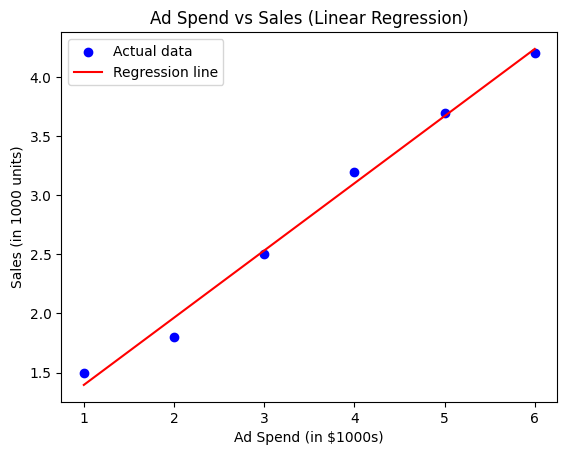

Predicted Sales for Ad_Spend = 7: 4.81 (in 1000 units)


/Users/damirdarasu/Documents/AI&DS/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# -----------------------------------
# 1) Dataset
# -----------------------------------
data = {
    "Ad_Spend": [1, 2, 3, 4, 5, 6],
    "Sales":    [1.5, 1.8, 2.5, 3.2, 3.7, 4.2]
}
df = pd.DataFrame(data)

X = df[["Ad_Spend"]]  # independent variable
y = df["Sales"]       # dependent variable

# -----------------------------------
# 2) Train Linear Regression model
# -----------------------------------
model = LinearRegression()
model.fit(X, y)

# Coefficients
slope = model.coef_[0]
intercept = model.intercept_

print(f"Equation of line: Sales = {intercept:.2f} + {slope:.2f} * Ad_Spend")

# -----------------------------------
# 3) Plot regression line and scatter plot
# -----------------------------------
plt.scatter(X, y, color="blue", label="Actual data")
plt.plot(X, model.predict(X), color="red", label="Regression line")
plt.xlabel("Ad Spend (in $1000s)")
plt.ylabel("Sales (in 1000 units)")
plt.title("Ad Spend vs Sales (Linear Regression)")
plt.legend()
plt.show()

# -----------------------------------
# 4) Prediction for Ad_Spend = 7
# -----------------------------------
predicted_sales = model.predict([[7]])
print(f"Predicted Sales for Ad_Spend = 7: {predicted_sales[0]:.2f} (in 1000 units)")


In [16]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, make_scorer

# ----------------------
# 1. Data
# ----------------------
data = {
    "Size": [850, 900, 1000, 1200, 1500, 1800, 2000],
    "Price": [200000, 220000, 240000, 260000, 300000, 340000, 370000]
}
df = pd.DataFrame(data)

X = df[["Size"]]
y = df["Price"]

# ----------------------
# 2. Define model
# ----------------------
model = LinearRegression()

# ----------------------
# 3. K-fold cross-validation (k=5)
# ----------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# scoring with negative MSE (sklearn convention)
mse_scores = cross_val_score(model, X, y, cv=kf,
                             scoring=make_scorer(mean_squared_error))

print("MSE for each fold:", mse_scores)
print("Average MSE:", np.mean(mse_scores))


MSE for each fold: [1.49275195e+08 6.75255100e+07 2.88650133e+05 1.70519253e+06
 3.88310190e+05]
Average MSE: 43836571.48897658


In [17]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Data
actual = np.array([100, 150, 200, 250, 300])
predicted = np.array([98, 145, 210, 240, 310])

# 1. Mean Absolute Error (MAE)
mae = mean_absolute_error(actual, predicted)

# 2. Mean Squared Error (MSE)
mse = mean_squared_error(actual, predicted)

# 3. Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# 4. R² Score
r2 = r2_score(actual, predicted)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)


Mean Absolute Error (MAE): 7.4
Mean Squared Error (MSE): 65.8
Root Mean Squared Error (RMSE): 8.1117199162693
R² Score: 0.98684


In [19]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Dataset
data = {
    "Age": [25, 30, 35, 40, 45, 50, 55],
    "Income": [30000, 35000, 40000, 50000, 60000, 65000, 70000],
    "Buy": [0, 0, 0, 1, 1, 1, 1]
}
df = pd.DataFrame(data)

X = df[["Age", "Income"]]
y = df["Buy"]

# Build model
model = LogisticRegression()
model.fit(X, y)

# Predict probability for Age=45, Income=60000
probability = model.predict_proba([[45, 60000]])[0][1]
print(f"Predicted probability of buying insurance: {probability:.2f}")

# Evaluate model
y_pred = model.predict(X)

print("Accuracy:", accuracy_score(y, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y, y_pred))
print("Classification Report:\n", classification_report(y, y_pred))


Predicted probability of buying insurance: 1.00
Accuracy: 1.0
Confusion Matrix:
 [[3 0]
 [0 4]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         4

    accuracy                           1.00         7
   macro avg       1.00      1.00      1.00         7
weighted avg       1.00      1.00      1.00         7



/Users/damirdarasu/Documents/AI&DS/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


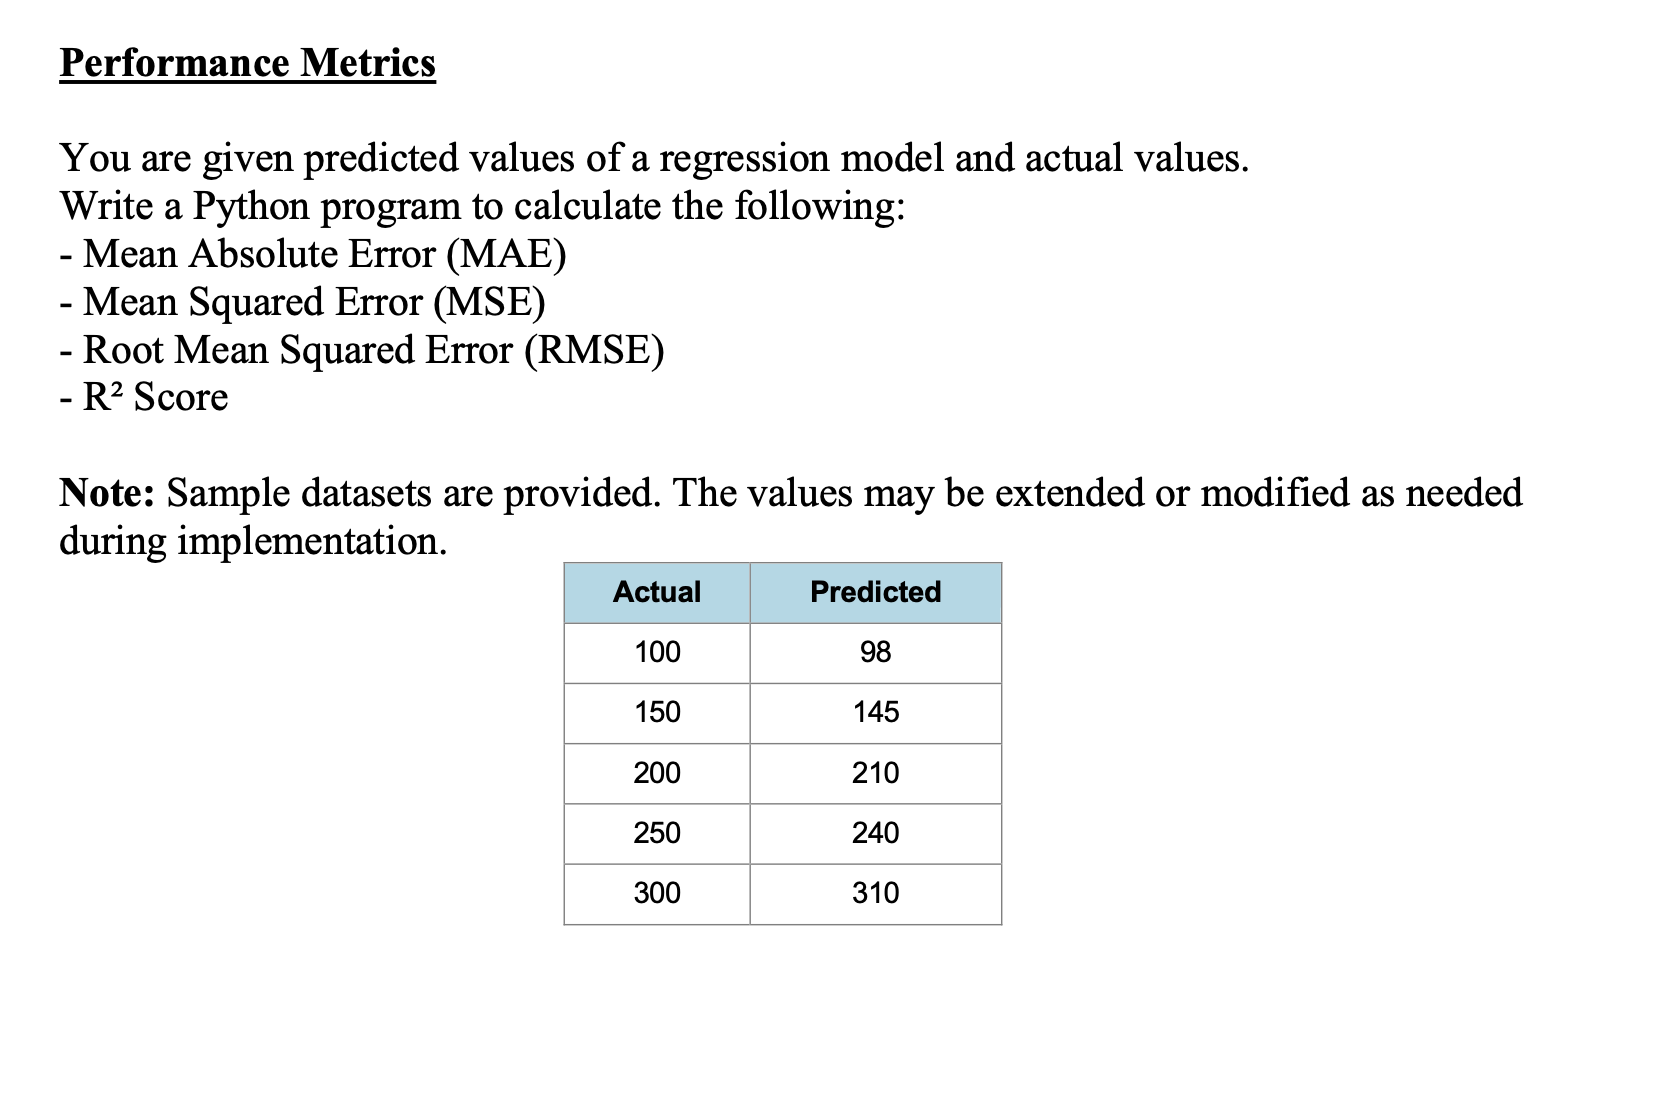